# PAMAP2: does our maths DETECT activity + OUTPUT regularity?
All told with plots. Orientation-proof features only. *(load cell ~20s)*

In [12]:
import numpy as np, pandas as pd, glob, re
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, confusion_matrix

PROTO = "/home/voare/Documents/Synheart/Kinematics/Dataset/PAMAP2_data/PAMAP2_Dataset/Protocol/*.dat"
keep = {1:"sedentary",2:"sedentary",3:"standing",4:"walking",7:"walking",5:"running",6:"cycling",24:"vigorous"}

def features(mag):                 # all 3 from |accel| -> all orientation-proof
    m = mag - mag.mean()
    ac = np.correlate(m, m, mode="full")[len(m)-1:]
    if ac[0] == 0: return mag.std(), 0.0, 0.0
    seg = (ac/ac[0])[15:128]; k = 15 + int(np.argmax(seg))
    return mag.std(), float(seg.max()), 100.0/k      # movement, regularity, cadence

rows = []
for f in glob.glob(PROTO):
    sid = int(re.search(r"subject(\d+)", f).group(1))
    d = pd.read_csv(f, sep=r"\s+", header=None)
    mag = np.sqrt((d[[4,5,6]].interpolate().to_numpy()**2).sum(1))
    aid = d[1].to_numpy(); N = 256
    for s in range(0, len(d)-N, N):
        seg = aid[s:s+N]
        if seg.min()!=seg.max() or seg[0] not in keep: continue
        mm = mag[s:s+N]
        if np.isnan(mm).any(): continue
        mv,rg,cd = features(mm); rows.append((sid, keep[seg[0]], mv, rg, cd))
df = pd.DataFrame(rows, columns=["subject","true","movement","regularity","cadence"])
df["true"] = df["true"].replace({"sedentary":"still","standing":"still"})
print("windows:", len(df))

windows: 5044


## 1. Activity State — DETECT what the person is doing
Tested on **unseen people** (train 7, test 2). The diagonal = correct detections.

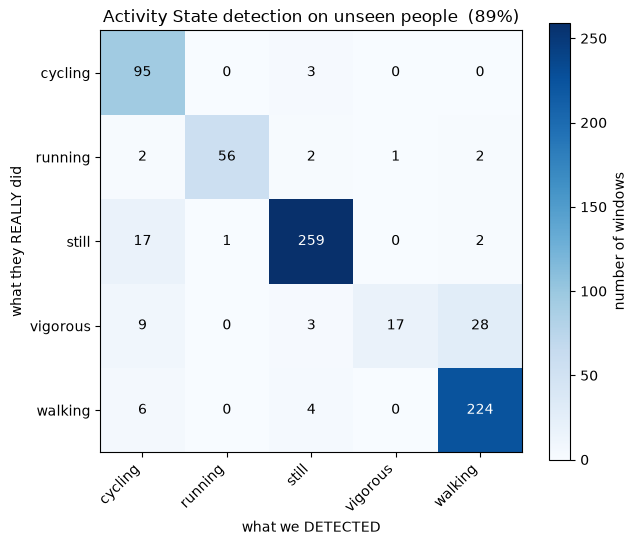

In [13]:
F = ["movement","regularity","cadence"]
tr = df[df.subject <= 107]; te = df[df.subject >= 108]
rule = DecisionTreeClassifier(max_depth=4, random_state=0).fit(tr[F], tr["true"])
pred = rule.predict(te[F]); acc = accuracy_score(te["true"], pred)

labels = sorted(te["true"].unique())
cm = confusion_matrix(te["true"], pred, labels=labels)
plt.figure(figsize=(6.5,5.5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.xlabel("what we DETECTED"); plt.ylabel("what they REALLY did")
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(label="number of windows")
plt.title(f"Activity State detection on unseen people  ({acc*100:.0f}%)")
plt.tight_layout(); plt.show()

### how well is each activity detected?

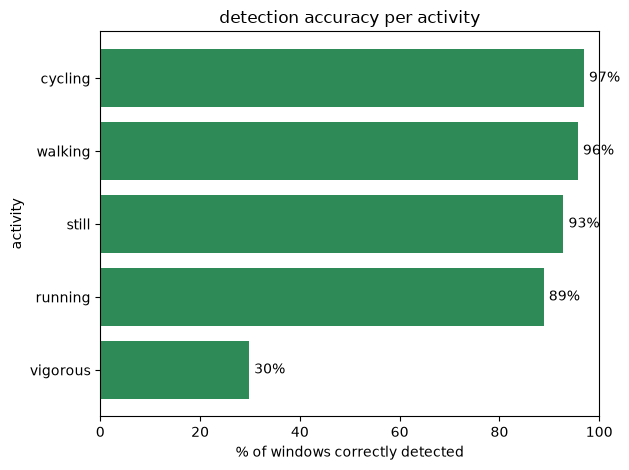

In [14]:
recall = cm.diagonal() / cm.sum(1) * 100
order = np.argsort(recall)
plt.barh([labels[i] for i in order], recall[order], color="seagreen")
plt.xlabel("% of windows correctly detected")          # x = recall
plt.ylabel("activity")                                 # y = activity
plt.title("detection accuracy per activity")
plt.xlim(0,100)
for i,v in enumerate(recall[order]): plt.text(v+1, i, f"{v:.0f}%", va="center")
plt.tight_layout(); plt.show()

### the deterministic rule it uses (if/else on our 3 numbers):

In [15]:
print(export_text(rule, feature_names=F))

|--- movement <= 1.44
|   |--- movement <= 0.86
|   |   |--- movement <= 0.12
|   |   |   |--- movement <= 0.11
|   |   |   |   |--- class: still
|   |   |   |--- movement >  0.11
|   |   |   |   |--- class: still
|   |   |--- movement >  0.12
|   |   |   |--- movement <= 0.12
|   |   |   |   |--- class: walking
|   |   |   |--- movement >  0.12
|   |   |   |   |--- class: still
|   |--- movement >  0.86
|   |   |--- regularity <= 0.24
|   |   |   |--- regularity <= 0.12
|   |   |   |   |--- class: still
|   |   |   |--- regularity >  0.12
|   |   |   |   |--- class: cycling
|   |   |--- regularity >  0.24
|   |   |   |--- cadence <= 0.88
|   |   |   |   |--- class: walking
|   |   |   |--- cadence >  0.88
|   |   |   |   |--- class: still
|--- movement >  1.44
|   |--- cadence <= 1.98
|   |   |--- regularity <= 0.25
|   |   |   |--- movement <= 6.35
|   |   |   |   |--- class: cycling
|   |   |   |--- movement >  6.35
|   |   |   |   |--- class: walking
|   |   |--- regularity >  0.25

## 2. Movement Regularity — how predictable is the movement?
Every window placed by **motion (x)** and **rhythm (y)**, colored by the verdict.

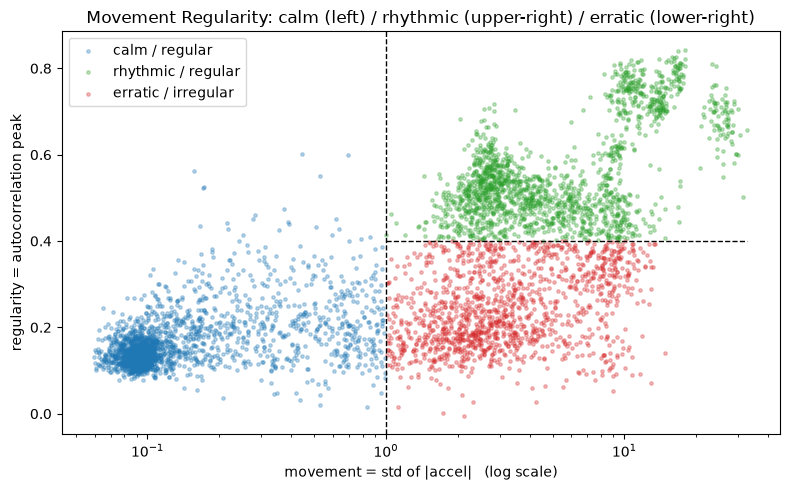

In [16]:
def regularity_output(movement, rhythm):
    if movement < 1.0:   return "calm / regular"          # still
    if rhythm > 0.40:    return "rhythmic / regular"        # steady walk/run
    return "erratic / irregular"                            # restless, household

df["verdict"] = [regularity_output(m, r) for m, r in zip(df.movement, df.regularity)]
colors = {"calm / regular":"tab:blue", "rhythmic / regular":"tab:green", "erratic / irregular":"tab:red"}

plt.figure(figsize=(8,5))
for v, c in colors.items():
    g = df[df.verdict == v]
    plt.scatter(g.movement, g.regularity, s=6, alpha=0.3, color=c, label=v)
plt.axvline(1.0, color="k", ls="--", lw=1)                 # movement threshold
plt.plot([1.0, df.movement.max()], [0.4, 0.4], "k--", lw=1) # rhythm threshold (right side)
plt.xscale("log")
plt.xlabel("movement = std of |accel|   (log scale)")      # x = how much motion
plt.ylabel("regularity = autocorrelation peak")            # y = how rhythmic
plt.title("Movement Regularity: calm (left) / rhythmic (upper-right) / erratic (lower-right)")
plt.legend(); plt.tight_layout(); plt.show()

## 3. Rotation test 

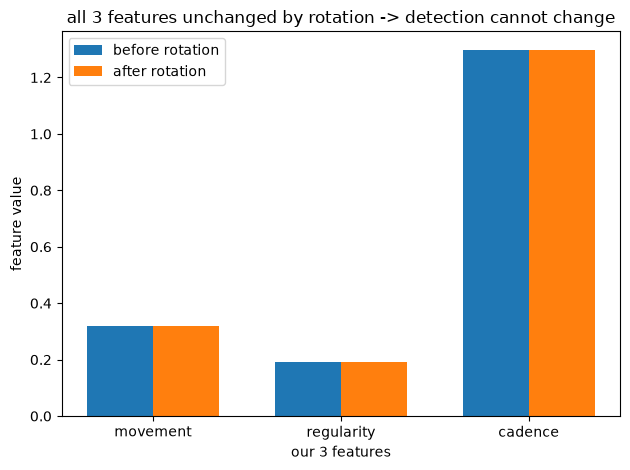

In [17]:
from scipy.spatial.transform import Rotation
d = pd.read_csv(glob.glob(PROTO)[0], sep=r"\s+", header=None)
win = d[d[1]==4][[4,5,6]].interpolate().to_numpy()[:256].T          # walking window (3,256)
R = Rotation.random(random_state=1).as_matrix()
def feats_xyz(xyz): return features(np.sqrt((xyz**2).sum(0)))
b = feats_xyz(win); a = feats_xyz(R @ win)

x = np.arange(3); w = 0.35
plt.bar(x-w/2, b, w, label="before rotation")
plt.bar(x+w/2, a, w, label="after rotation")
plt.xticks(x, F); plt.ylabel("feature value")              # y = feature value
plt.xlabel("our 3 features")                               # x = which feature
plt.title("all 3 features unchanged by rotation -> detection cannot change")
plt.legend(); plt.tight_layout(); plt.show()